In [1]:
import netCDF4 as nc
import xarray as xr
import numpy as np
import gcsfs
import time
from pathlib import Path
from calendar import monthrange
from dinosaur import xarray_utils
from functools import partial
import time
import pandas as pd
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import tcmarkers

from ty_pkg import truncate_colormap, colorline, setup_map, weather_map_contour, contourf_and_save, ep_t, concentric_circles, interpolate_data, set_map
from ty_pkg import latlon_extent, storm_info, haversine_distance, Met, calculate_bearing_position, tc_finder, WindFieldSolver, find_large_groups

/home1/jek/miniconda3/envs/pangu/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# <span style="color:yellow; background-color:gray;">**Central difference & OW parameter & Area weighting mean**</span>

-   **Main Idea**   
    <div style="font-size: 17px;">
    OW parameter is too fluctuate to catch up the large domain Deformation flow<br> 
    Vorticity, Stretching, Shear can be integrated in the certain area(ex. circular area from certain point)<br>  

    => If it's possible it can induce Large Scale OW parameter<br>  
    </div>
  
- data shape: (lat, lon)


In [4]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance using Haversine formula.
    Args:
        lat1, lon1: Coordinates of the first point (radians)
        lat2, lon2: Coordinates of the second point (radians)
    Returns:
        Distance in kilometers
    """
    R = 6371.0  # Earth radius in km
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def calculate_dx_dy(lat, lon):
    """
    Calculate variable dx and dy for given latitude and longitude.
    Args:
        lat: 2D array of latitudes (degrees)
        lon: 2D array of longitudes (degrees)
    Returns:
        dx, dy: 2D arrays of grid spacing in kilometers
    """

    R = 6371.0*1000                      # Radius of Earth (km)

    # Convert degrees to radians
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    
    # Calculate spacing
    dlat = np.gradient(lat_rad, axis=0)  # Change in latitude (radians)
    dlon = np.gradient(lon_rad, axis=1)  # Change in longitude (radians)

    # dx and dy
    dx = R * np.cos(lat_rad) * dlon  # Adjust for latitude
    dy = R * dlat                   # Latitude spacing is uniform in y-direction

    return dx, dy

def central_difference(data, axis, dx):
    """
    Compute the derivative of a 2D array using central difference, supporting variable dx.
    Args:
        data: 2D numpy array
        axis: Axis along which to compute the derivative (0 or 1)
        dx: 2D numpy array of grid spacing
    Returns:
        2D numpy array of derivatives
    """
    derivative = np.zeros_like(data)

    if axis == 0:  # Derivative along x-axis
        derivative[1:-1, :] = (data[2:, :] - data[:-2, :]) / (2 * dx[1:-1, :])
        # Boundary points
        derivative[0, :] = (data[1, :] - data[0, :]) / dx[0, :]
        derivative[-1, :] = (data[-1, :] - data[-2, :]) / dx[-1, :]
    elif axis == 1:  # Derivative along y-axis
        derivative[:, 1:-1] = (data[:, 2:] - data[:, :-2]) / (2 * dx[:, 1:-1])
        # Boundary points
        derivative[:, 0] = (data[:, 1] - data[:, 0]) / dx[:, 0]
        derivative[:, -1] = (data[:, -1] - data[:, -2]) / dx[:, -1]

    return derivative


def calculate_vss(u, v, lat, lon):
    """
    Compute the OW parameter on a latitude-longitude grid.
    Args:
        u, v: 2D arrays of velocity components (m/s)
        lat, lon: 2D arrays of latitude and longitude (degrees)
    Returns:
        OW: 2D array of OW parameter
    """
    # Calculate variable grid spacing
    dx, dy = calculate_dx_dy(lat, lon)

    # 코드 예시
    dudy = central_difference(u, axis=0, dx=dy)  # lat 방향 = axis=0
    dudx = central_difference(u, axis=1, dx=dx)  # lon 방향 = axis=1
    dvdy = central_difference(v, axis=0, dx=dy)
    dvdx = central_difference(v, axis=1, dx=dx)
    # Deformation terms
    S1 = dudx - dvdy  # Normal deformation
    S2 = dvdx + dudy  # Shear deformation

    # Vorticity term
    zeta = dvdx - dudy

    # OW parameter
    # S_total = S1**2 + S2**2
    # OW = (S_total-(zeta**2))/(zeta**2)

    return S1, S2, zeta

def calculate_all_avg_ow(u, v, lat, lon, radius=200):
    """
    Calculate weighted averages of S1, S2, zeta for all points as centers within a circular region.
    Args:
        S1, S2, zeta: 2D arrays of values
        lat, lon: 2D arrays of latitudes and longitudes (degrees)
        radius: Radius of the circular region (km)
    Returns:
        3D arrays of weighted averages (same shape as S1, S2, zeta)
    """
    # Convert degrees to radians
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)

    S1, S2, zeta = calculate_vss(u, v, lat, lon)
    # plt.imshow(zeta)
    # plt.show()

    # Initialize arrays for results
    S1_avg = np.zeros_like(S1)
    S2_avg = np.zeros_like(S2)
    zeta_avg = np.zeros_like(zeta)

    # Loop over each grid point
    for i in range(lat.shape[0]):
        for j in range(lat.shape[1]):
            # Current center point
            lat_c = lat_rad[i, j]
            lon_c = lon_rad[i, j]

            # Calculate distances from the center
            distances = haversine(lat_c, lon_c, lat_rad, lon_rad)

            # Mask for points within the radius
            mask = distances <= radius

            # Calculate weightsb according to the points' gaps increase
            weights = np.cos(lat_rad[mask])

            # Calculate weighted averages
            if np.sum(weights) > 0:
                S1_avg[i, j] = np.sum(S1[mask] * weights) / np.sum(weights)
                S2_avg[i, j] = np.sum(S2[mask] * weights) / np.sum(weights)
                zeta_avg[i, j] = np.sum(zeta[mask] * weights) / np.sum(weights)

    return S1_avg, S2_avg, zeta_avg

# <span style="color:yellow; background-color:gray">**Load ERA5 data and Draw OW parameter**</span>

Min OW: -2.6692201637698774e-10, Max OW: 1.4869110011756339e-09


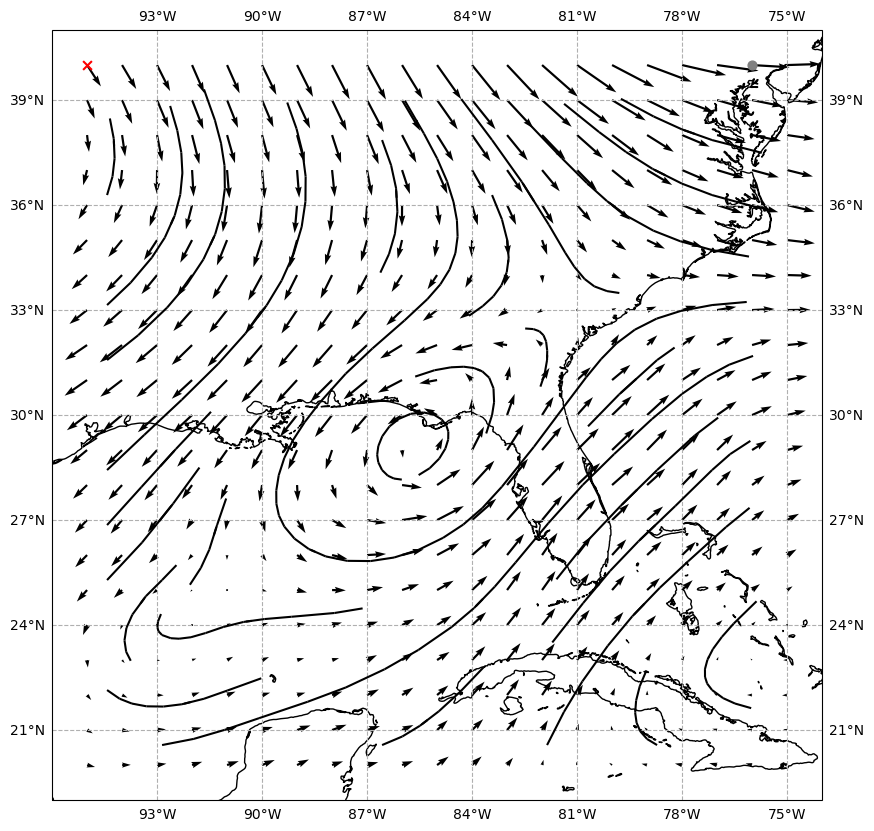

(21, 21)


In [15]:
data_dir = "/data05/KIST_precip/data"
year = 2012
month = 6
day = 25
hour = 12

# pressure_list = [850]
pressure_list = [850, 825, 800, 775, 750, 700, 650, 600, 550, 500, 450, 400, 350, 300, 250]

# Set Lon, Lat extent
# lon_min, lon_max = 0, 360
# lat_min, lat_max = -90, 90
# lon_min, lon_max = 110, 160       # East Asia   
lat_min, lat_max = 20, 40
lon_min, lon_max = 265, 285     # Atlantic Ocean
# lon_min, lon_max = 265, 360     # Atlantic Ocean

grid_size = 4                     # Data Grid size 
radius = 1000                      # Radius of the circular region (km) to weighting avg of S1, S2, zeta
# scale_size = 5e-10                # OW parameter scale size
scale_size = 1e-09


# Load data
u = (xr.open_dataset(f"/data06/ERA5/hourly/u/ERA5_u_{year}{month:02d}.nc")
     .sel(
         pressure_level = pressure_list,
         valid_time = f"{year}-{month:02d}-{day}-{hour:02d}",
         longitude=slice(lon_min, lon_max),
         latitude=slice(lat_max, lat_min)  # 위도는 내림차순일 수 있음
     )).isel(
    longitude=slice(None, None, grid_size),  
    latitude=slice(None, None, grid_size)    
    )

v = (xr.open_dataset(f"/data06/ERA5/hourly/v/ERA5_v_{year}{month:02d}.nc")
     .sel(
         pressure_level = pressure_list,
         valid_time = f"{year}-{month:02d}-{day}-{hour:02d}",
         longitude=slice(lon_min, lon_max),
         latitude=slice(lat_max, lat_min)  # 위도는 내림차순일 수 있음
     )).isel(
    longitude=slice(None, None, grid_size),  
    latitude=slice(None, None, grid_size)    
    )

lon = u["longitude"].values
lat = u["latitude"].values

# u
if len(pressure_list) == 1:
    u = u["u"].values[0]
    v = v["v"].values[0]
else:
    u = u["u"].values
    v = v["v"].values
    # Calculate pressure differences (weights)
    pressure_diff = np.abs(np.diff(pressure_list))  # Absolute differences
    weights = np.concatenate(([pressure_diff[0]], pressure_diff))  # Include weight for first level

    # Calculate weighted average along the pressure axis
    u = np.average(u, axis=0, weights=weights)
    v = np.average(v, axis=0, weights=weights)

lons, lats = np.meshgrid(lon, lat)
lons -=180
s1, s2, zeta = calculate_all_avg_ow(u, v, lats, lons, radius=radius)
ss = s1**2 + s2**2 - zeta**2
# ss = s1**2 + s2**2

scale_number = int(float(str(scale_size).split('e')[0]))          #scale_size의 정수부분
print(f"Min OW: {np.min(ss)}, Max OW: {np.max(ss)}")

# Plot
fig, ax = plt.subplots(figsize = (10,10), subplot_kw={'projection': ccrs.PlateCarree(180)})
ax.coastlines("10m")
ax.gridlines(draw_labels=True, linestyle='--')

# cfax = ax.contourf(lons, lats, ow, cmap = "gist_ncar", levels = np.linspace(-scale_size, scale_size, 100), extend = "both")
# cfax = ax.contourf(lons, lats, ss, cmap = "gist_ncar", levels = np.linspace(0, scale_size, 100), extend = "both")
# cax = ax.contour(lons, lats, ow, levels = np.linspace(-scale_size,-scale_size/5,5), colors = "black")
# cax = ax.contour(lons, lats, ss, levels = np.linspace(scale_size/5,scale_size,5), colors = "black")
quiver_grid = 4 if grid_size == 1 else 2 if grid_size == 2 else 1
# quiver_grid = 8 if grid_size == 1 else 4 if grid_size == 2 else 2
ax.quiver(lons[::quiver_grid,::quiver_grid], lats[::quiver_grid,::quiver_grid], u[::quiver_grid,::quiver_grid], v[::quiver_grid,::quiver_grid])

ax.streamplot(lons[::quiver_grid,::quiver_grid], lats[::quiver_grid,::quiver_grid], u[::quiver_grid,::quiver_grid], v[::quiver_grid,::quiver_grid], density=0.5, color = 'black', arrowstyle='-', zorder = 3)

# Find ss min, max point & scatter
min_idx, max_idx = np.argmin(ss), np.argmax(ss)
min_lon, min_lat = lons.flatten()[min_idx], lats.flatten()[min_idx]
max_lon, max_lat = lons.flatten()[max_idx], lats.flatten()[max_idx]
ax.scatter(min_lon, min_lat, color = "red", s = 40, marker = "x")
ax.scatter(max_lon, max_lat, color = "grey", s = 40)

# cbar = plt.colorbar(cfax, orientation='horizontal', shrink=0.8, pad = 0.05)
# cbar.add_lines(cax)  # cax (contour)의 레벨을 컬러바에 추가
# cbar.set_label("$OW parameter(s^{-2}$)")
# # cbar.set_label("$Stretching^2 + Shear^2(s^{-2}$)")
# cbar.set_ticks(np.linspace(0, scale_size, scale_number+1))
plt.show()

print(np.shape(u))

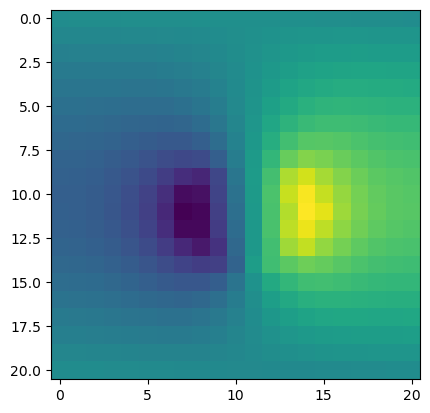

In [16]:
deform_dir = '/home1/jek/deform/TC_data'
storm_name = 'Debby'
storm_year = 2012
# storm_lon, storm_lat, storm_mslp, storm_time = storm_info(deform_dir, storm_name, storm_year, wind_thres=0)

# TC_lon = -87.40; TC_lat = 26.50
TC_lat = 28.30 ;TC_lon = -86.00
TC_lat = 27.60 ;TC_lon = -86.80
TC_lat = 28.90	;TC_lon = -84.30
# 지구 반지름
R = 6.371e6  # meters

lons, lats = np.meshgrid(lon-360, lat)
# 위도, 경도를 라디안으로 변환
lat_rad = np.radians(lats)
lon_rad = np.radians(lons)

# 위도/경도 간격 (라디안 기준)
dlat = np.gradient(lat_rad, axis=0)
dlon = np.gradient(lon_rad, axis=1)

# 거리 기준 간격
dx = R * np.cos(lat_rad) * dlon  # (남북 간격마다 다름)
dy = R * dlat                    # (동서 간격마다 다름)

# 각도 → 거리로 환산하여 gradient 계산
du_dy = np.gradient(u, axis=0) / dy
dv_dx = np.gradient(v, axis=1) / dx
vort = dv_dx - du_dy

du_dx = np.gradient(u, axis=1) / dx
dv_dy = np.gradient(v, axis=0) / dy
div = du_dx + dv_dy
# ty_wind = WindFieldSolver(lats, lons, TC_lat, TC_lon, vort, div)
ty_wind = WindFieldSolver(lats, lons, TC_lat, TC_lon, div, vort, radius=333, dx=111e3/4*grid_size, dy=111e3/4*grid_size)
u_ty, v_ty = ty_wind.solve()

plt.imshow(v_ty)

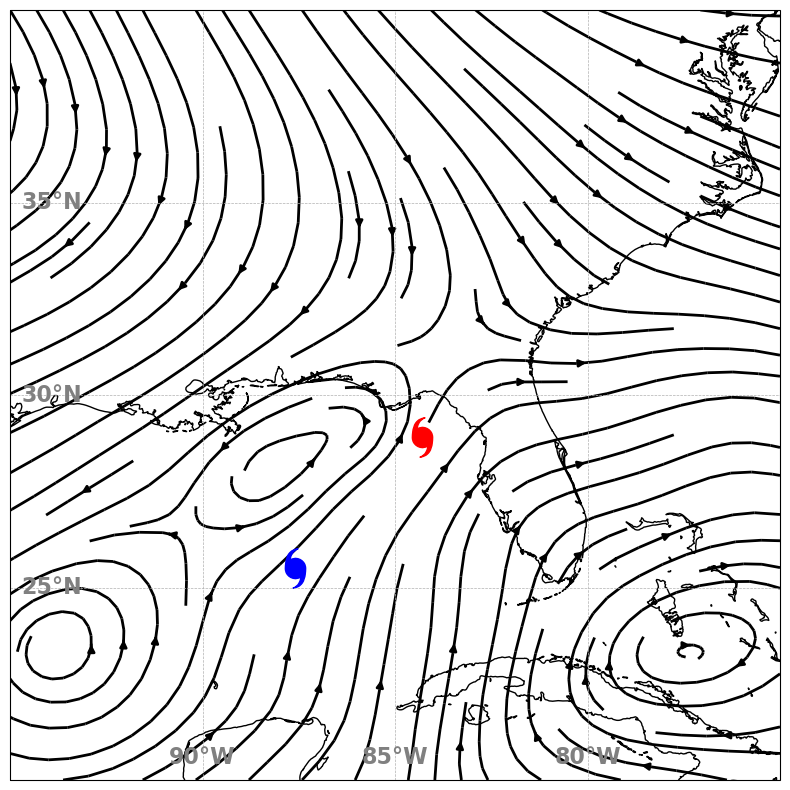

In [17]:
import numpy as np
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

fig, ax = plt.subplots(figsize = (10,10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(
    [lons.min(), lons.max(), lats.min(), lats.max()],
    crs=ccrs.PlateCarree()
)
# ax.quiver(lons[::quiver_grid,::quiver_grid], lats[::quiver_grid,::quiver_grid], u_ty[::quiver_grid,::quiver_grid], v_ty[::quiver_grid,::quiver_grid])
ax.coastlines("10m")
# ax.quiver(lons[::quiver_grid,::quiver_grid], lats[::quiver_grid,::quiver_grid], (u-u_ty)[::quiver_grid,::quiver_grid], (v-v_ty)[::quiver_grid,::quiver_grid], scale = 10000)
ax.streamplot(
    lons[::quiver_grid, ::quiver_grid],
    lats[::quiver_grid, ::quiver_grid],
    (u - u_ty)[::quiver_grid, ::quiver_grid],
    (v - v_ty)[::quiver_grid, ::quiver_grid],
    transform=ccrs.PlateCarree(),   # ← 꼭 추가
    density=1, linewidth=2, zorder = 1, color = 'black'        # 필요하면 조정
)
# ❸ 5° 간격 그리드라인
gl = ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.5)

# 5° 간격
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 5))
gl.ylocator = mticker.FixedLocator(np.arange(-90,  91, 5))

# ▷ 라벨을 안쪽에, 글꼴 크게
gl.xpadding = -8          # 음수 ⇒ 축 안쪽으로
gl.ypadding = -8
gl.xlabel_style = {'size': 16, 'weight': 'bold', 'color': 'gray'}   # 원하는 만큼 키워도 됨
gl.ylabel_style = {'size': 16, 'weight': 'bold', 'color': 'gray'}   # 원하는 만큼 키워도 됨

# 필요 없으면 끄기
gl.top_labels   = False
gl.right_labels = False
# ax.scatter(-87.40,26.50, transform=ccrs.PlateCarree(), color = "blue", s = 200, marker=tcmarkers.HU)
ax.scatter(-87.60,25.50, transform=ccrs.PlateCarree(), color = "blue", s = 200, marker=tcmarkers.HU)
ax.scatter(-84.30,28.90	, transform=ccrs.PlateCarree(), color = "red", s = 200, marker=tcmarkers.HU)
# ax.scatter(-86.80,27.60	, transform=ccrs.PlateCarree(), color = "red", s = 200, marker=tcmarkers.HU)
# ax.scatter(-86.00,28.30, transform=ccrs.PlateCarree(), color = "red", s = 200, marker=tcmarkers.HU)

In [ ]:
lon_sub = lons[::quiver_grid, ::quiver_grid]
lat_sub = lats[::quiver_grid, ::quiver_grid]
u_sub   = (u - u_ty)[::quiver_grid, ::quiver_grid]
v_sub   = (v - v_ty)[::quiver_grid, ::quiver_grid]

print(lon_sub.shape, lat_sub.shape, u_sub.shape)

(21, 21) (21, 21) (21, 21)


In [102]:
lons

array([[-95., -94., -93., -92., -91., -90., -89., -88., -87., -86., -85.,
        -84., -83., -82., -81., -80., -79., -78., -77., -76., -75.],
       [-95., -94., -93., -92., -91., -90., -89., -88., -87., -86., -85.,
        -84., -83., -82., -81., -80., -79., -78., -77., -76., -75.],
       [-95., -94., -93., -92., -91., -90., -89., -88., -87., -86., -85.,
        -84., -83., -82., -81., -80., -79., -78., -77., -76., -75.],
       [-95., -94., -93., -92., -91., -90., -89., -88., -87., -86., -85.,
        -84., -83., -82., -81., -80., -79., -78., -77., -76., -75.],
       [-95., -94., -93., -92., -91., -90., -89., -88., -87., -86., -85.,
        -84., -83., -82., -81., -80., -79., -78., -77., -76., -75.],
       [-95., -94., -93., -92., -91., -90., -89., -88., -87., -86., -85.,
        -84., -83., -82., -81., -80., -79., -78., -77., -76., -75.],
       [-95., -94., -93., -92., -91., -90., -89., -88., -87., -86., -85.,
        -84., -83., -82., -81., -80., -79., -78., -77., -76., -75.],

# <span style="color:yellow; background-color:gray">**Monthly mean ow parameter**</span>

Processing: 2016-06-01 00:00 UTC
Processing: 2016-06-02 00:00 UTC
Processing: 2016-06-03 00:00 UTC
Processing: 2016-06-04 00:00 UTC
Processing: 2016-06-05 00:00 UTC
Processing: 2016-06-06 00:00 UTC
Processing: 2016-06-07 00:00 UTC
Processing: 2016-06-08 00:00 UTC
Processing: 2016-06-09 00:00 UTC
Processing: 2016-06-10 00:00 UTC
Processing: 2016-06-11 00:00 UTC
Processing: 2016-06-12 00:00 UTC
Processing: 2016-06-13 00:00 UTC
Processing: 2016-06-14 00:00 UTC
Processing: 2016-06-15 00:00 UTC
Processing: 2016-06-16 00:00 UTC
Processing: 2016-06-17 00:00 UTC
Processing: 2016-06-18 00:00 UTC
Processing: 2016-06-19 00:00 UTC
Processing: 2016-06-20 00:00 UTC
Processing: 2016-06-21 00:00 UTC
Processing: 2016-06-22 00:00 UTC
Processing: 2016-06-23 00:00 UTC
Processing: 2016-06-24 00:00 UTC
Processing: 2016-06-25 00:00 UTC
Processing: 2016-06-26 00:00 UTC
Processing: 2016-06-27 00:00 UTC
Processing: 2016-06-28 00:00 UTC
Processing: 2016-06-29 00:00 UTC
Processing: 2016-06-30 00:00 UTC
Processing

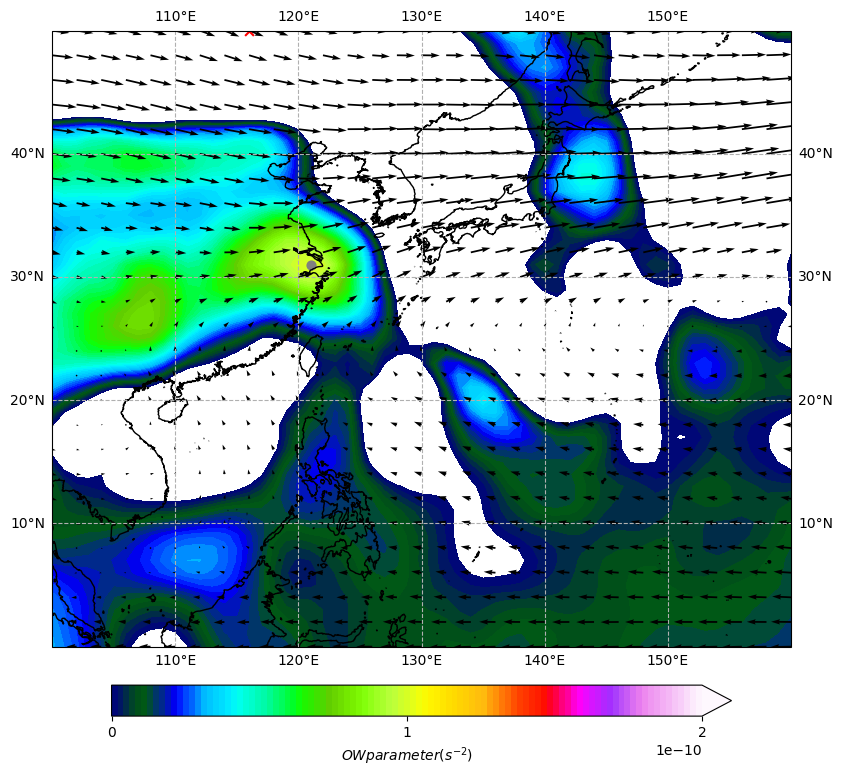

✅ 평균 OW parameter 계산 완료! 데이터 개수: 460


In [ ]:
# 데이터 경로
data_dir = "/data05/KIST_precip/data"

# 분석 기간 설정
start_date = "2016-06-01 00:00"
end_date = "2020-08-31 23:00"
month_list = [6,7,8]
hour_step = 24
time_range = pd.date_range(start=start_date, end=end_date, freq=f"{hour_step}H")  # 6시간 간격
# ✅ 8월 데이터만 필터링
time_range = time_range[time_range.month.isin(month_list)]

# 기압 수준 설정
pressure_list = [850, 825, 800, 775, 750, 700, 650, 600, 550, 500, 450, 400, 350, 300, 250]

# 경위도 범위 설정
lon_min, lon_max = 100, 160  # East Asia   
# lon_min, lon_max = 240, 300     # Atlantic Ocean
lat_min, lat_max = 0, 50
grid_size = 4  # 데이터 격자 크기
radius = 500  # OW parameter 계산 반경 (km)
scale_size = 2e-10  # OW parameter 스케일 크기

# OW parameter 저장 리스트
ow_list = []
u_list = []
v_list = []

# 특정 기간 동안의 데이터를 처리
for timestamp in time_range:
    year, month, day, hour = timestamp.year, timestamp.month, timestamp.day, timestamp.hour
    print(f"Processing: {year}-{month:02d}-{day:02d} {hour:02d}:00 UTC")

    # 데이터 로드
    try:
        u = xr.open_dataset(f"/data06/ERA5/hourly/u/ERA5_u_{year}{month:02d}.nc").sel(
            pressure_level=pressure_list,
            valid_time=f"{year}-{month:02d}-{day:02d}-{hour:02d}",
            longitude=slice(lon_min, lon_max),
            latitude=slice(lat_max, lat_min)
        ).isel(
            longitude=slice(None, None, 4),  # 4개씩 건너뛰기
            latitude=slice(None, None, 4)
        )

        v = xr.open_dataset(f"/data06/ERA5/hourly/v/ERA5_v_{year}{month:02d}.nc").sel(
            pressure_level=pressure_list,
            valid_time=f"{year}-{month:02d}-{day:02d}-{hour:02d}",
            longitude=slice(lon_min, lon_max),
            latitude=slice(lat_max, lat_min)
        ).isel(
            longitude=slice(None, None, 4),  # 4개씩 건너뛰기
            latitude=slice(None, None, 4)
        )

        # 좌표 정보
        lon = u["longitude"].values
        lat = u["latitude"].values

        # 압력 축 가중 평균
        if len(pressure_list) == 1:
            u = u["u"].values[0]
            v = v["v"].values[0]
        else:
            u = u["u"].values
            v = v["v"].values
            pressure_diff = np.abs(np.diff(pressure_list))
            weights = np.concatenate(([pressure_diff[0]], pressure_diff))
            u = np.average(u, axis=0, weights=weights)
            v = np.average(v, axis=0, weights=weights)

        # OW parameter 계산
        lons, lats = np.meshgrid(lon, lat)
        lons -= 180  # -180 ~ 180 범위로 변환
        s1, s2, zeta = calculate_all_avg_ow(u, v, lats, lons, radius=radius)
        ow = s1**2 + s2**2 - zeta**2
        ow_list.append(ow)
        u_list.append(u)
        v_list.append(v)

    except Exception as e:
        print(f"⚠️ Error processing {timestamp}: {e}")
        continue

# ✅ 평균 OW parameter 계산
ow_mean = np.mean(ow_list, axis=0)
u_mean = np.mean(u_list, axis=0)
v_mean = np.mean(v_list, axis=0)

# ✅ 시각화
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree(180)})
ax.coastlines("10m")
ax.gridlines(draw_labels=True, linestyle='--')

# 컬러맵 시각화
cfax = ax.contourf(lons, lats, ow_mean, cmap="gist_ncar", levels=np.linspace(0, scale_size, 100), extend="max")
# cax = ax.contour(lons, lats, ow_mean, levels=np.linspace(scale_size/5, scale_size, 5), colors="black")

# 바람 벡터 시각화
quiver_grid = 2 if grid_size == 4 else 1
ax.quiver(lons[::quiver_grid, ::quiver_grid], lats[::quiver_grid, ::quiver_grid],
          u_mean[::quiver_grid, ::quiver_grid], v_mean[::quiver_grid, ::quiver_grid])

# 최소/최대 OW parameter 지점 찾기
min_idx, max_idx = np.argmin(ow_mean), np.argmax(ow_mean)
min_lon, min_lat = lons.flatten()[min_idx], lats.flatten()[min_idx]
max_lon, max_lat = lons.flatten()[max_idx], lats.flatten()[max_idx]
ax.scatter(min_lon, min_lat, color="red", s=40, marker="x")
ax.scatter(max_lon, max_lat, color="grey", s=40)

# 컬러바 추가
cbar = plt.colorbar(cfax, orientation='horizontal', shrink=0.8, pad=0.05)
# cbar.add_lines(cax)
cbar.set_label("$OW parameter (s^{-2})$")
cbar.set_ticks(np.linspace(0, scale_size, int(float(str(scale_size).split('e')[0])) + 1))

plt.show()

print(f"✅ 평균 OW parameter 계산 완료! 데이터 개수: {len(ow_list)}")


# <span style="color:yellow; background-color:gray">**Seasonal ow parameter difference**</span>

In [ ]:
# 데이터 경로
data_dir = "/data05/KIST_precip/data"

# 분석 기간 설정
old_start_date = "1981-06-01 00:00"
old_end_date = "2000-08-31 23:00"
new_start_date = "2001-06-01 00:00"
new_end_date = "2020-08-31 23:00"
month_list = [6,7,8]
hour_step = 24

old_time_range = pd.date_range(start=old_start_date, end=old_end_date, freq=f"{hour_step}H")  # 6시간 간격
old_time_range = old_time_range[old_time_range.month.isin(month_list)]
new_time_range = pd.date_range(start=new_start_date, end=new_end_date, freq=f"{hour_step}H")  # 6시간 간격
new_time_range = new_time_range[new_time_range.month.isin(month_list)]

# 기압 수준 설정
pressure_list = [850, 825, 800, 775, 750, 700, 650, 600, 550, 500, 450, 400, 350, 300, 250]

# 경위도 범위 설정
lon_min, lon_max = 100, 160  # East Asia   
# lon_min, lon_max = 240, 300     # Atlantic Ocean
lat_min, lat_max = 0, 50
grid_size = 4  # 데이터 격자 크기
radius = 500  # OW parameter 계산 반경 (km)
scale_size = 2e-10  # OW parameter 스케일 크기

# OW parameter 저장 리스트
old_ow_list = []
new_ow_list = []


# 특정 기간 동안의 데이터를 처리
for time_range in [old_time_range, new_time_range]:
    for timestamp in time_range:
        year, month, day, hour = timestamp.year, timestamp.month, timestamp.day, timestamp.hour
        print(f"Processing: {year}-{month:02d}-{day:02d} {hour:02d}:00 UTC")

        # 데이터 로드
        try:
            u = xr.open_dataset(f"/data06/ERA5/hourly/u/ERA5_u_{year}{month:02d}.nc").sel(
                pressure_level=pressure_list,
                valid_time=f"{year}-{month:02d}-{day:02d}-{hour:02d}",
                longitude=slice(lon_min, lon_max),
                latitude=slice(lat_max, lat_min)
            ).isel(
                longitude=slice(None, None, 4),  # 4개씩 건너뛰기
                latitude=slice(None, None, 4)
            )

            v = xr.open_dataset(f"/data06/ERA5/hourly/v/ERA5_v_{year}{month:02d}.nc").sel(
                pressure_level=pressure_list,
                valid_time=f"{year}-{month:02d}-{day:02d}-{hour:02d}",
                longitude=slice(lon_min, lon_max),
                latitude=slice(lat_max, lat_min)
            ).isel(
                longitude=slice(None, None, 4),  # 4개씩 건너뛰기
                latitude=slice(None, None, 4)
            )

            # 좌표 정보
            lon = u["longitude"].values
            lat = u["latitude"].values

            # 압력 축 가중 평균
            if len(pressure_list) == 1:
                u = u["u"].values[0]
                v = v["v"].values[0]
            else:
                u = u["u"].values
                v = v["v"].values
                pressure_diff = np.abs(np.diff(pressure_list))
                weights = np.concatenate(([pressure_diff[0]], pressure_diff))
                u = np.average(u, axis=0, weights=weights)
                v = np.average(v, axis=0, weights=weights)

            # OW parameter 계산
            lons, lats = np.meshgrid(lon, lat)
            lons -= 180  # -180 ~ 180 범위로 변환
            s1, s2, zeta = calculate_all_avg_ow(u, v, lats, lons, radius=radius)
            ow = s1**2 + s2**2 - zeta**2
            if time_range is old_time_range:
                old_ow_list.append(ow)
            elif time_range is new_time_range:
                new_ow_list.append(ow)

        except Exception as e:
            print(f"⚠️ Error processing {timestamp}: {e}")
            continue

# ✅ 평균 OW parameter 계산
old_ow_mean = np.mean(old_ow_list, axis=0)
new_ow_mean = np.mean(new_ow_list, axis=0)


# ✅ 시각화
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree(180)})
ax.coastlines("10m")
ax.gridlines(draw_labels=True, linestyle='--')

# 컬러맵 시각화
cfax = ax.contourf(lons, lats, ow_mean, cmap="gist_ncar", levels=np.linspace(0, scale_size, 100), extend="max")
# cax = ax.contour(lons, lats, ow_mean, levels=np.linspace(scale_size/5, scale_size, 5), colors="black")

# 바람 벡터 시각화
quiver_grid = 2 if grid_size == 4 else 1
ax.quiver(lons[::quiver_grid, ::quiver_grid], lats[::quiver_grid, ::quiver_grid],
          u_mean[::quiver_grid, ::quiver_grid], v_mean[::quiver_grid, ::quiver_grid])

# 최소/최대 OW parameter 지점 찾기
min_idx, max_idx = np.argmin(ow_mean), np.argmax(ow_mean)
min_lon, min_lat = lons.flatten()[min_idx], lats.flatten()[min_idx]
max_lon, max_lat = lons.flatten()[max_idx], lats.flatten()[max_idx]
ax.scatter(min_lon, min_lat, color="red", s=40, marker="x")
ax.scatter(max_lon, max_lat, color="grey", s=40)

# 컬러바 추가
cbar = plt.colorbar(cfax, orientation='horizontal', shrink=0.8, pad=0.05)
# cbar.add_lines(cax)
cbar.set_label("$OW parameter (s^{-2})$")
cbar.set_ticks(np.linspace(0, scale_size, int(float(str(scale_size).split('e')[0])) + 1))

plt.show()

print(f"✅ 평균 OW parameter 계산 완료! 데이터 개수: {len(ow_list)}")


In [16]:
u_data = xr.open_mfdataset(f"/data06/ERA5/hourly/u/ERA5_u_{year}{month:02d}.nc")
v_data = xr.open_mfdataset(f"/data06/ERA5/hourly/v/ERA5_v_{year}{month:02d}.nc")

# 선택한 기압 수준 및 영역에서 데이터 추출 후 시간 평균 계산
u = u_data.sel(
    pressure_level=pressure_list,
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_max, lat_min)  # 위도는 내림차순일 수 있음
)

v = v_data.sel(
    pressure_level=pressure_list,
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_max, lat_min)
)

print(u["u"].values.shape)

(124, 15, 41, 41)
